Target Point Index: 358


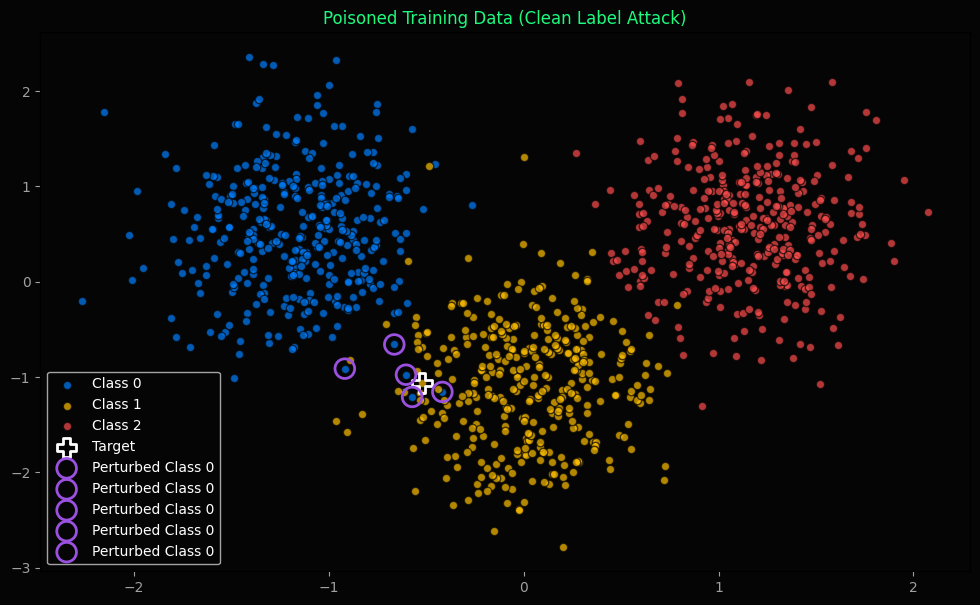

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.multiclass import OneVsRestClassifier

# --- 1. CONFIGURATION & THEME ---
SEED = 1337
np.random.seed(SEED)

# HTB Theme Colors (Fixes the NameError)
azure = "#007fff"
nugget_yellow = "#ffbf00"
malware_red = "#ff4d4d"
hacker_grey = "#a0a0a0"
node_black = "#050505"
htb_green = "#1dfa7d"
vivid_purple = "#9b51e0"
white = "#ffffff"

# --- 2. DATA GENERATION ---
n_samples = 1500
centers_3class = [(0, 6), (4, 3), (8, 6)] 
X_3c, y_3c = make_blobs(
    n_samples=n_samples,
    centers=centers_3class,
    n_features=2,
    cluster_std=1.15,
    random_state=SEED,
)

scaler = StandardScaler()
X_3c_scaled = scaler.fit_transform(X_3c)

X_train_3c, X_test_3c, y_train_3c, y_test_3c = train_test_split(
    X_3c_scaled, y_3c, test_size=0.3, random_state=SEED, stratify=y_3c
)

# --- 3. HELPER FUNCTIONS ---
def plot_data_multi(X, y, title, highlight_indices=None, highlight_markers=None, highlight_colors=None, highlight_labels=None):
    plt.figure(figsize=(12, 7))
    class_colors = [azure, nugget_yellow, malware_red]
    for i, color in enumerate(class_colors):
        mask = (y == i)
        plt.scatter(X[mask, 0], X[mask, 1], c=color, label=f"Class {i}", edgecolors=node_black, alpha=0.7)
    
    if highlight_indices:
        for i, idx in enumerate(highlight_indices):
            plt.scatter(X[idx, 0], X[idx, 1], edgecolors=highlight_colors[i], marker=highlight_markers[i], s=200, linewidths=2, facecolors='none', label=highlight_labels[i])
    
    plt.title(title, color=htb_green)
    plt.legend()
    plt.show()

# --- 4. BASELINE MODEL TRAINING ---
base_estimator = LogisticRegression(random_state=SEED, C=1.0, solver="liblinear")
baseline_model_3c = OneVsRestClassifier(base_estimator)
baseline_model_3c.fit(X_train_3c, y_train_3c)

# Extract parameters for Class 0 vs Class 1
estimators_base = baseline_model_3c.estimators_
w0_base, b0_base = estimators_base[0].coef_[0], estimators_base[0].intercept_[0]
w1_base, b1_base = estimators_base[1].coef_[0], estimators_base[1].intercept_[0]
w_diff_01_base = w0_base - w1_base
b_diff_01_base = b0_base - b1_base

# --- 5. SELECT TARGET POINT ---
class1_indices = np.where(y_train_3c == 1)[0]
decision_values = X_train_3c[class1_indices] @ w_diff_01_base + b_diff_01_base
target_point_index_absolute = class1_indices[np.argmax(decision_values[decision_values < 0])]
X_target = X_train_3c[target_point_index_absolute]

# --- 6. IMPLEMENT CLEAN LABEL ATTACK ---
n_neighbors_to_perturb = 5
class0_indices = np.where(y_train_3c == 0)[0]
X_class0 = X_train_3c[class0_indices]

nn_finder = NearestNeighbors(n_neighbors=n_neighbors_to_perturb)
nn_finder.fit(X_class0)
_, indices_rel = nn_finder.kneighbors(X_target.reshape(1, -1))
neighbor_indices_absolute = class0_indices[indices_rel.flatten()]

# Calculate Perturbation
push_direction = -w_diff_01_base
unit_push_direction = push_direction / np.linalg.norm(push_direction)
epsilon_cross = 0.25
delta = epsilon_cross * unit_push_direction

# Poison the data
X_train_poisoned = X_train_3c.copy()
for idx in neighbor_indices_absolute:
    X_train_poisoned[idx] += delta

# --- 7. VISUALIZE RESULTS ---
print(f"Target Point Index: {target_point_index_absolute}")
plot_data_multi(
    X_train_poisoned, y_train_3c, 
    title="Poisoned Training Data (Clean Label Attack)",
    highlight_indices=[target_point_index_absolute] + list(neighbor_indices_absolute),
    highlight_markers=["P"] + ["o"] * n_neighbors_to_perturb,
    highlight_colors=[white] + [vivid_purple] * n_neighbors_to_perturb,
    highlight_labels=["Target"] + ["Perturbed Class 0"] * n_neighbors_to_perturb
)